# 03 · Consolidated results
Every table and figure here is read from `reports/` (written by the pipeline); nothing is
recomputed. Run `python -m aml.cli data features detect train` first.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd

from aml.config import load_config

cfg = load_config()
TAB, FIG = cfg.root / cfg.paths.tables_dir, cfg.root / cfg.paths.figures_dir
pd.options.display.float_format = "{:,.4f}".format

def table(name, **kw):
    path = TAB / name
    return pd.read_csv(path, **kw) if path.exists() else pd.DataFrame({"missing": [name]})

def figure(name, width=9):
    path = FIG / name
    if not path.exists():
        print(f"missing figure: {name}"); return
    img = mpimg.imread(path)
    fig, ax = plt.subplots(figsize=(width, width * img.shape[0] / img.shape[1]))
    ax.imshow(img); ax.axis("off"); plt.show()

## 1. Data

,transactions,accounts,banks,first_ts,last_ts,span_days
0,5078345,515088,30528,2022-09-01,2022-09-18 16:18:00,17.6792


,is_laundering,n,share_pct
0,0,5073168,99.8981
1,1,5177,0.1019


,grp,n,ill,rate_pct
0,ACH,600797,"4,483.0000",0.7462
1,Bitcoin,146091,56.0000,0.0383
2,Cash,490891,108.0000,0.0220
3,Cheque,1864331,324.0000,0.0174
4,Credit Card,1323324,206.0000,0.0156
5,Wire,171855,0.0000,0.0000
6,Reinvestment,481056,0.0000,0.0000


,currency,usd_per_unit,via,n_obs,hops
0,Bitcoin,"11,882.6111",US Dollar,25,1
1,UK Pound,1.2917,US Dollar,2041,1
2,Euro,1.1718,US Dollar,13043,1
3,Swiss Franc,1.0929,US Dollar,2221,1
4,US Dollar,1.0000,US Dollar,0,0
5,Canadian Dollar,0.7580,US Dollar,1298,1
6,Australian Dollar,0.7078,US Dollar,1239,1
7,Shekel,0.2961,US Dollar,2012,1
8,Saudi Riyal,0.2666,US Dollar,781,1
9,Brazil Real,0.1771,US Dollar,720,1


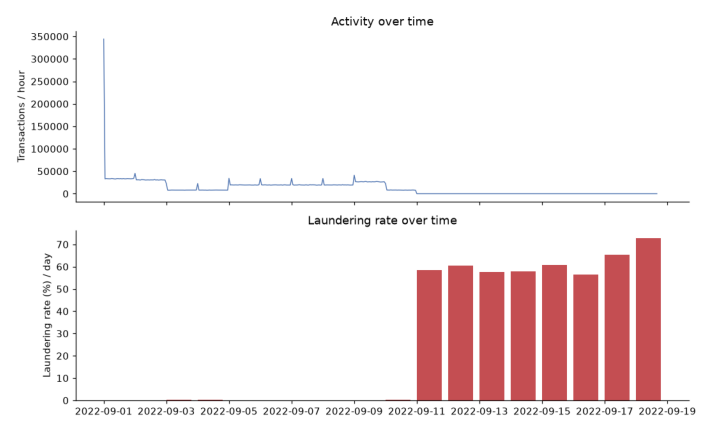

In [2]:
display(table("eda_scale.csv")); display(table("eda_class_balance.csv"))
display(table("eda_rate_by_format.csv")); display(table("fx_rates.csv"))
figure("eda_activity_over_time.png")

## 2. Graph structure

,n_components,largest,non_trivial (size>1),nodes_in_non_trivial
strong,494769,17075,2928,23247
weak,114139,372089,21785,422734


,transactions,in_nontrivial_scc,share_pct
all,"4,487,133.0000","221,352.0000",4.9330
laundering,"5,166.0000","1,212.0000",23.4611


,illicit_accounts,context_accounts,context_pairs,laundering_pairs,context_share_of_accounts_pct
0,6357,64067,82238,4929,12.4381


,account,k,nodes,edges,seconds
0,small illicit account,1,4,42,0.4300
1,small illicit account,2,14,128,0.7600
2,small illicit account,3,300,2973,1.0000
3,largest hub,1,300,2718,0.5000
4,largest hub,2,300,2718,0.7500
5,largest hub,3,300,2718,0.8200


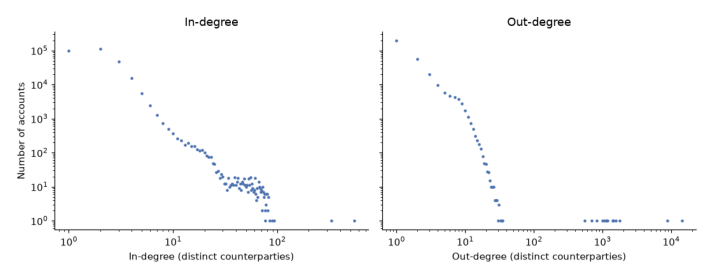

In [3]:
display(table("graph_components.csv", index_col=0)); display(table("graph_scc_share.csv", index_col=0))
display(table("graph_illicit_context.csv")); display(table("graph_ego_timing.csv"))
figure("graph_degree_distributions.png")

## 3. Rule-based detectors
Recall: share of laundering attempts with at least half their transactions covered.
Diagonal cells matter; small attempts are covered by coincidence (see attempt-size table).

In [4]:
display(table("detector_recall_by_typology.csv", index_col=0))
display(table("detector_precision.csv", index_col=0))
display(table("detector_recall_by_attempt_size.csv")); display(table("detector_cycle_recall_by_hops.csv"))

,n_attempts,fan_in,fan_out,gather_scatter,pass_through,scatter_gather,temporal_cycle,any_detector
typology,,,,,,,,
BIPARTITE,49,0.0204,0.0000,0.3061,0.1020,0.0204,0.3469,0.5510
CYCLE,54,0.0000,0.0000,0.3889,0.1481,0.0000,0.5926,0.7778
FAN-IN,40,0.0750,0.0000,0.2500,0.0500,0.0000,0.2500,0.4000
FAN-OUT,48,0.0208,0.2917,0.3333,0.0417,0.0417,0.2917,0.6667
GATHER-SCATTER,51,0.0392,0.2549,0.8431,0.0392,0.0000,0.2549,0.9412
RANDOM,41,0.0000,0.0000,0.2927,0.0244,0.0732,0.3902,0.5854
SCATTER-GATHER,44,0.0227,0.2727,0.4091,0.0909,0.6364,0.3182,1.0000
STACK,43,0.0000,0.0000,0.3488,0.0465,0.0465,0.3256,0.5116
ALL,370,0.0216,0.1054,0.4054,0.0703,0.0973,0.3514,0.6892


,n_findings,n_txns,n_laundering,precision,recall_all,recall_attributed,finding_precision
detector,,,,,,,
fan_in,1390,46363,202,0.0044,0.0390,0.0305,0.0029
fan_out,1597,72537,581,0.0080,0.1122,0.1786,0.0207
gather_scatter,11505,850036,1594,0.0019,0.3079,0.4668,0.0019
pass_through,2195,113469,149,0.0013,0.0288,0.0396,0.0055
scatter_gather,197,1705,578,0.3390,0.1116,0.1795,0.1726
temporal_cycle,1022,1666,302,0.1813,0.0583,0.0857,0.3297
ANY,17906,1040624,2443,0.0023,0.4719,0.6831,NaN


,size_bucket,attempts,detected
0,1-2,112,0.9107
1,3-5,55,0.6545
2,6-10,80,0.4625
3,>10,123,0.6504


,hop_bucket,attempts,detected
0,<=2,14,1.0000
1,3,9,1.0000
2,4-6,11,0.8182
3,>6,20,0.0000


## 4. Unsupervised account anomaly detection

,pr_auc,precision@100,precision@500,precision@1000,flag_precision,flag_recall,n_accounts,n_illicit
method,,,,,,,,
isolation_forest,0.0411,0.3100,0.1460,0.1230,NaN,NaN,422734,6357
lof,0.0263,0.0000,0.0440,0.0470,NaN,NaN,422734,6357
hdbscan,0.0183,0.0223,0.0223,0.0223,0.0201,0.3467,422734,6357
ensemble,0.0377,0.3100,0.1440,0.1050,NaN,NaN,422734,6357
random (seeded draw),0.0149,0.0400,0.0160,0.0130,NaN,NaN,422734,6357
random (expected),0.0150,0.0150,0.0150,0.0150,NaN,NaN,422734,6357


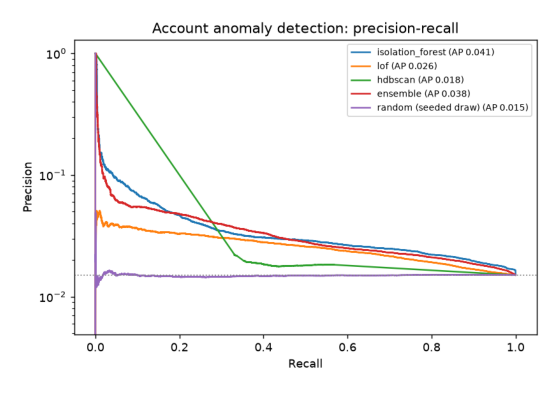

In [5]:
display(table("anomaly_results.csv", index_col=0)); figure("anomaly_pr_curves.png", 7)

## 5. Supervised transaction model (temporal split)
The test window straddles the late period in which licit activity collapses, so the
`test_before_11sep` / `test_from_11sep` rows separate the two regimes.

,n,n_positive,threshold,pr_auc,precision,recall,f1,tn,fp,fn,tp,precision@100,precision@500,precision@1000
validation,"1,015,669.0000","1,082.0000",0.4610,0.5236,0.6931,0.4445,0.5417,"1,014,374.0000",213.0000,601.0000,481.0000,0.9900,0.8200,0.5400
test,"1,015,669.0000","1,797.0000",0.4610,0.5870,0.8905,0.4162,0.5673,"1,013,780.0000",92.0000,"1,049.0000",748.0000,0.9900,0.9820,0.8270
test_before_11sep,"1,014,561.0000","1,142.0000",0.4610,0.4074,0.8054,0.2898,0.4263,"1,013,339.0000",80.0000,811.0000,331.0000,0.9900,0.7280,0.4560
test_from_11sep,"1,108.0000",655.0000,0.4610,0.9676,0.9720,0.6366,0.7694,441.0000,12.0000,238.0000,417.0000,0.9900,0.9540,0.6550


,n_test_txns,recall
typology,,
BIPARTITE,74,0.2297
CYCLE,109,0.4954
FAN-IN,137,0.5474
FAN-OUT,140,0.8000
GATHER-SCATTER,401,0.6459
RANDOM,86,0.3256
SCATTER-GATHER,252,0.6111
STACK,140,0.3357
UNATTRIBUTED,458,0.0044


,gain
pair_seen_before,"734,111.7282"
snd_in_usd_7d,"469,543.3380"
payment_format,"336,243.9622"
log_amt_usd,"287,609.3966"
rcv_in_dcp_1d,"116,736.4934"
snd_in_usd_30d,"89,436.6463"
rcv_in_cnt_7d,"55,500.6788"
rcv_in_usd_7d,"48,917.2696"
snd_in_cnt_7d,"47,504.2793"
snd_out_cnt_7d,"33,566.5227"


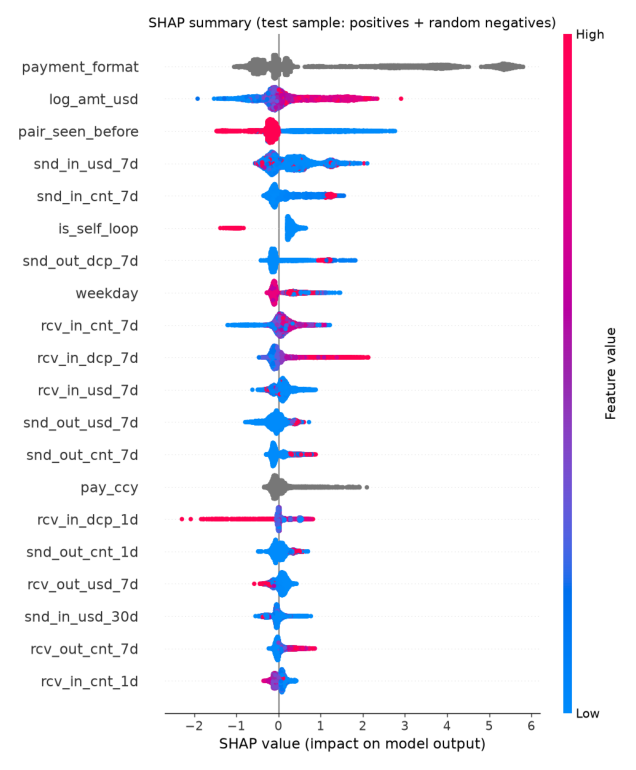

In [6]:
display(table("supervised_metrics.csv", index_col=0))
display(table("supervised_recall_by_typology.csv", index_col=0))
display(table("supervised_feature_importance.csv", index_col=0).head(15))
figure("shap_summary.png", 8)